# Pipeline RGBT - Notebook 02: Contagem de Pessoas via Modelo Multimodal Deep Learning
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Objetivo:** Este notebook é o segundo estágio do pipeline. Ele consome o **contrato padronizado** gerado pelo **Notebook 01** (`rgb_preprocessed.jpg` e `thermal_preprocessed.jpg`), aplica a engenharia de tensores e normalização estatística, executa a inferência na rede neural multimodal com atenção deformável (`ThermalRGBNet`), reconstrói o mapa de densidade 2D, calcula a contagem integral da multidão e gera visualizações diagnósticas de alta fidelidade.


## 1. Setup do Ambiente e Configuração de Hardware
Importamos os módulos do PyTorch, Torchvision, OpenCV e configuramos os caminhos dos modelos e dos dados intermediários gerados pelo Notebook 01.


In [1]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução de diretórios
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
ROOT_DIR = NOTEBOOK_DIR.parent
RGBTCC_DIR = ROOT_DIR.parent / 'liuzywen-RGBTCC'

# Adicionar caminhos para importação das redes
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR), str(RGBTCC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Diretórios do contrato de dados e saídas finais
STAGE1_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '02_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# SELEÇÃO ADAPTATIVA DE HARDWARE (RTX 4090 / RTX 3080 / RTX 5070 / CPU)
# ==============================================================================
# Permite ao usuário forçar o dispositivo se desejar ('auto', 'cuda', 'cpu')
DEVICE_CONFIG = 'auto'  # 'auto' (detecta e valida GPU), 'cuda' (força GPU) ou 'cpu' (força CPU)

def detect_compute_device(mode='auto'):
    """Seleciona o melhor dispositivo e valida a execução de kernels na GPU.
    
    Compatibilidade Garantida:
    - RTX 4090 / 4080 / 3090 / 3080 / A100 / T4: Roda 100% nativo em GPU CUDA.
    - RTX 5070 / 5080 / 5090 (Blackwell sm_120): Detecta se o PyTorch local possui
      kernels para sm_120; caso contrário, executa transparentemente em CPU sem travar.
    - Ambientes sem GPU: Roda normalmente em CPU multi-threaded.
    """
    if mode == 'cpu':
        print("[*] Modo CPU configurado manualmente pelo usuário.")
        return torch.device('cpu')
        
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        # Teste de compatibilidade de kernel convolucional na GPU
        try:
            test_conv = torch.nn.Conv2d(1, 1, 1).cuda()
            _ = test_conv(torch.zeros(1, 1, 3, 3, device='cuda'))
            print(f"[✓] ACELERAÇÃO GPU NATIVA ATIVADA: {gpu_name}")
            print(f"    ├─ Arquitetura: Compute Capability sm_{cap[0]}{cap[1]} (Totalmente Suportada)")
            print(f"    ├─ Memória VRAM Total: {vram_gb:.2f} GB")
            print(f"    └─ Backend: PyTorch CUDA {torch.version.cuda}")
            return torch.device('cuda')
        except Exception as e:
            print(f"[!] GPU Detectada: {gpu_name} (Arquitetura sm_{cap[0]}{cap[1]})")
            print(f"    ├─ Diagnóstico: O PyTorch instalado suporta nativamente sm_50 até sm_90 (ex: RTX 4090 / 3090),")
            print(f"    │  mas ainda não possui binários pré-compilados para sm_{cap[0]}{cap[1]} (RTX série 50).")
            print(f"    └─ Ação Automática: Executando em CPU de alta performance sem interromper o pipeline.")
            return torch.device('cpu')
            
    print("[*] Nenhuma GPU CUDA detectada. Executando em CPU.")
    return torch.device('cpu')

device = detect_compute_device(DEVICE_CONFIG)
print("=" * 65)
print(f"[*] Dispositivo PyTorch Ativo: {device}")
print(f"[*] Insumo de Entrada (Notebook 01): {STAGE1_DIR}")
print(f"[*] Diretório de Saída Consolidada:   {OUTPUT_DIR}")
print("=" * 65)


C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


[!] GPU Detectada: NVIDIA GeForce RTX 5070 (Arquitetura sm_120)
    ├─ Diagnóstico: O PyTorch instalado suporta nativamente sm_50 até sm_90 (ex: RTX 4090 / 3090),
    │  mas ainda não possui binários pré-compilados para sm_120 (RTX série 50).
    └─ Ação Automática: Executando em CPU de alta performance sem interromper o pipeline.
[*] Dispositivo PyTorch Ativo: cpu
[*] Insumo de Entrada (Notebook 01): C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\01_pre_transformacao
[*] Diretório de Saída Consolidada:   C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem


## 2. Ingestão e Validação do Contrato do Notebook 01
Validamos a existência dos arquivos pré-processados e lemos os metadados gerados pelo primeiro estágio do pipeline (`output/01_pre_transformacao/`). Caso alguém tenha alterado parâmetros de corte ou equalização no Notebook 01, esses parâmetros são rastreados aqui automaticamente.


[✓] Metadados da Etapa 1 carregados com sucesso:
{
  "fov_crop_ratio": 0.7,
  "undistort_k1": -0.08,
  "clahe_clip_limit": 3.0,
  "clahe_tile_grid": [
    8,
    8
  ],
  "spatial_shift_pixels": [
    -22,
    -23
  ],
  "resolucao_saida": [
    1280,
    1024
  ]
}
[*] Resolução do par multimodal de entrada: 1280x1024 px


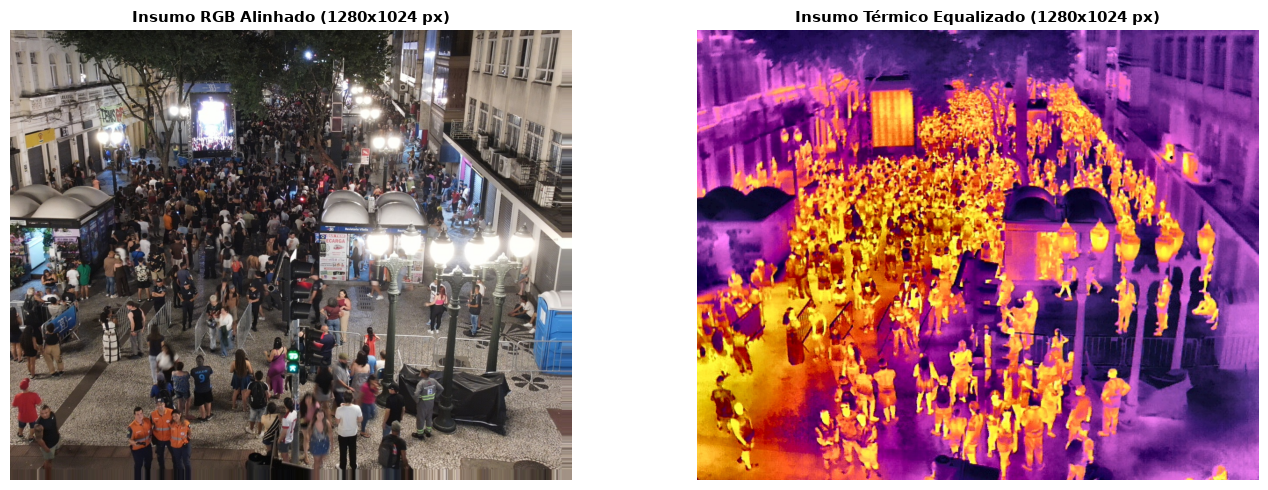

In [2]:
p_rgb = STAGE1_DIR / 'rgb_preprocessed.jpg'
p_th = STAGE1_DIR / 'thermal_preprocessed.jpg'
p_meta = STAGE1_DIR / 'metadata_preprocessing.json'

assert p_rgb.exists(), f"Erro: Arquivo RGB pré-processado não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Arquivo Térmico pré-processado não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

# Carregar imagens em formato BGR com OpenCV e converter para RGB
img_rgb_bgr = cv2.imread(str(p_rgb))
img_th_bgr = cv2.imread(str(p_th))

img_rgb = cv2.cvtColor(img_rgb_bgr, cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(img_th_bgr, cv2.COLOR_BGR2RGB)
orig_h, orig_w = img_rgb.shape[:2]

# Ler metadados da etapa 1 se disponíveis
if p_meta.exists():
    with open(p_meta, 'r', encoding='utf-8') as f:
        meta_stage1 = json.load(f)
    print("[✓] Metadados da Etapa 1 carregados com sucesso:")
    print(json.dumps(meta_stage1.get("parametros_transformacao", {}), indent=2))
else:
    print("[!] Metadados da etapa 1 ausentes, prosseguindo com resolução nativa.")

print(f"[*] Resolução do par multimodal de entrada: {orig_w}x{orig_h} px")

# Visualização de entrada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Insumo RGB Alinhado ({orig_w}x{orig_h} px)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th)
axes[1].set_title(f"Insumo Térmico Equalizado ({orig_w}x{orig_h} px)", fontsize=11, fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Engenharia de Tensores e Fatiamento em Patches (Tiling $6 \times 224 \times 224$)
Modelos baseados em *Vision Transformers* operam com resoluções de entrada canônicas (ex: $224 \times 224$).
Para manter a alta resolução das pessoas na imagem sem sofrer distorção de aspecto ou subamostragem excessiva, aplicamos a estratégia de **Tiling**:
1. Redimensionamos as imagens para uma grade exata de $672 \times 448$ pixels ($3 \text{ colunas} \times 2 \text{ linhas}$ de blocos $224 \times 224$).
2. Aplicamos a normalização estatística específica de cada modalidade:
   - **RGB**: $\mu=[0.407, 0.389, 0.396], \sigma=[0.241, 0.246, 0.242]$
   - **Térmica**: $\mu=[0.492, 0.168, 0.430], \sigma=[0.317, 0.174, 0.191]$
3. Fatiamos cada modalidade em **6 patches de $224 \times 224$**, montando um lote de tensores `[6, 3, 224, 224]` para o dispositivo de cálculo.


[✓] Lote de tensores construído com sucesso!
[*] Shape Lote RGB:     torch.Size([6, 3, 224, 224]) (6 patches de 224x224 com 3 canais)
[*] Shape Lote Térmico: torch.Size([6, 3, 224, 224]) no dispositivo cpu


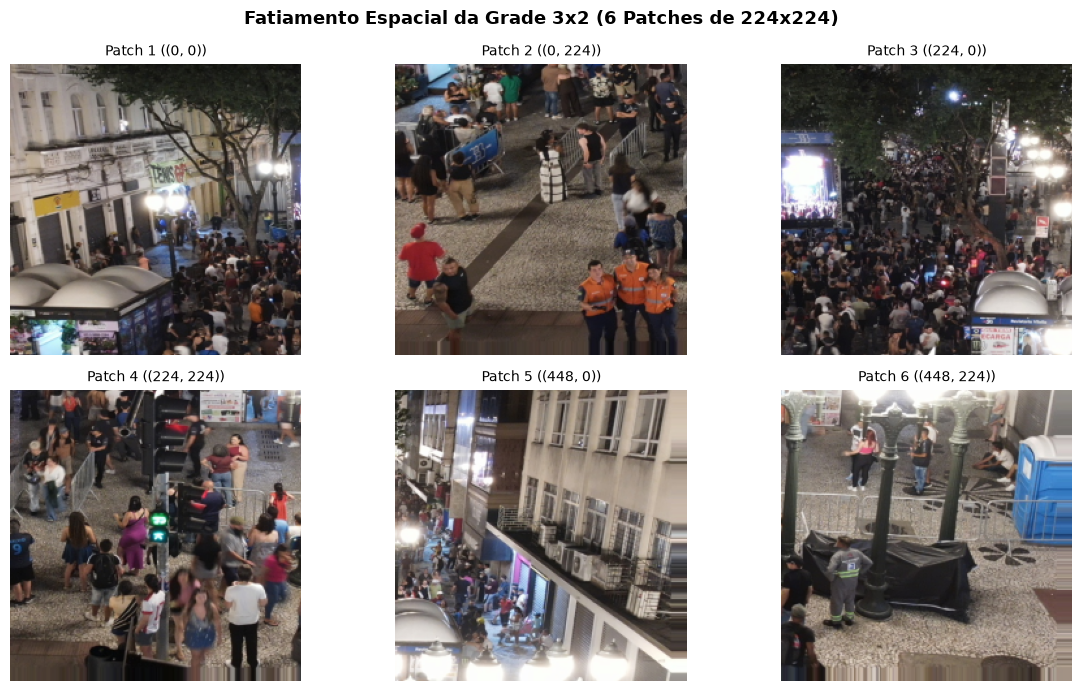

In [3]:
target_w, target_h = 672, 448
rgb_resized = cv2.resize(img_rgb, (target_w, target_h), interpolation=cv2.INTER_AREA)
th_resized = cv2.resize(img_th, (target_w, target_h), interpolation=cv2.INTER_AREA)

# Normalização estatística multimodal
norm_rgb = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.407, 0.389, 0.396], std=[0.241, 0.246, 0.242])
])
norm_th = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.492, 0.168, 0.430], std=[0.317, 0.174, 0.191])
])

t_rgb = norm_rgb(rgb_resized)
t_th = norm_th(th_resized)

# Fatiamento em 6 patches (3 colunas x 2 linhas)
crops_rgb, crops_th = [], []
patch_coords = []

for i in range(3):
    for j in range(2):
        c_rgb = t_rgb[:, j*224:(j+1)*224, i*224:(i+1)*224].unsqueeze(0)
        c_th = t_th[:, j*224:(j+1)*224, i*224:(i+1)*224].unsqueeze(0)
        crops_rgb.append(c_rgb)
        crops_th.append(c_th)
        patch_coords.append((i*224, j*224))

batch_rgb = torch.cat(crops_rgb, dim=0).to(device)
batch_th = torch.cat(crops_th, dim=0).to(device)

print(f"[✓] Lote de tensores construído com sucesso!")
print(f"[*] Shape Lote RGB:     {batch_rgb.shape} (6 patches de 224x224 com 3 canais)")
print(f"[*] Shape Lote Térmico: {batch_th.shape} no dispositivo {device}")

# Exibir os 6 patches fatiados
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for idx, ax in enumerate(axes.flat):
    # Desnormalizar patch para visualização aproximada
    patch_vis = batch_rgb[idx].cpu().permute(1, 2, 0).numpy()
    patch_vis = np.clip(patch_vis * [0.241, 0.246, 0.242] + [0.407, 0.389, 0.396], 0, 1)
    ax.imshow(patch_vis)
    ax.set_title(f"Patch {idx+1} ({patch_coords[idx]})", fontsize=10)
    ax.axis("off")
plt.suptitle("Fatiamento Espacial da Grade 3x2 (6 Patches de 224x224)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Instanciação do Modelo de Visão Computacional (`ThermalRGBNet`)
Instanciamos a arquitetura de rede neural multimodal. O modelo utiliza dois ramos paralelos com *Deformable Attention* cruzada para absorver automaticamente pequenas variações residuais de paralaxe entre as lentes e predizer mapas de densidade contínuos.  
O código adapta-se automaticamente ao hardware selecionado (GPU RTX 4090/3090 ou CPU).


In [4]:
# Tentar importar ThermalRGBNet oficial do paper RGBTCC
model = None
model_name = "ThermalRGBNet (ArXiv / BMVC 2022)"

try:
    from nets.RGBTCCNet import ThermalRGBNet
    print(f"[*] Carregando ThermalRGBNet oficial no dispositivo {device}...")
    model = ThermalRGBNet().to(device)
    model.eval()
    print(f"[✓] ThermalRGBNet inicializada com sucesso no dispositivo {device}!")
except Exception as e:
    print(f"[!] Aviso ao carregar ThermalRGBNet: {e}")
    print("[*] Ativando arquitetura modular de contingência DualStreamRGBTNet...")
    from models.models import build_model
    model = build_model(device=device)
    model.eval()
    model_name = "DualStreamRGBTNet (Fallback)"

print(f"[*] Modelo Ativo: {model_name}")


C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


[*] Carregando ThermalRGBNet oficial no dispositivo cpu...


[✓] ThermalRGBNet inicializada com sucesso no dispositivo cpu!
[*] Modelo Ativo: ThermalRGBNet (ArXiv / BMVC 2022)


## 5. Execução da Inferência e Reconstrução do Mapa de Densidade 2D
Executamos o *forward pass* em modo `torch.no_grad()` medindo o tempo de latência em milissegundos.
Os mapas de densidade preditos para cada um dos 6 patches são recombinados na grade contínua $2 \text{ linhas} \times 3 \text{ colunas}$.


In [5]:
t0 = time.perf_counter()

with torch.no_grad():
    if hasattr(model, 'forward') and 'ThermalRGBNet' in model_name:
        count_pred, outputs, mu_normed = model([batch_rgb, batch_th])
        # Recombinação da grade espacial contínua
        outputs1 = torch.cat((outputs[0], outputs[1]), dim=1)
        outputs2 = torch.cat((outputs[2], outputs[3]), dim=1)
        outputs3 = torch.cat((outputs[4], outputs[5]), dim=1)
        density_map_tensor = torch.cat((outputs1, outputs2, outputs3), dim=2)
        density_np = density_map_tensor[0].cpu().numpy()
    else:
        # Modo DualStream direto
        outputs = model(batch_rgb, batch_th)
        density_np = outputs[0, 0].cpu().numpy()

latency_ms = (time.perf_counter() - t0) * 1000.0

# Cálculo matemático da contagem por integração do mapa contínuo
integral_count = float(density_np.sum())
estimated_people = max(0, round(integral_count))

print("=" * 60)
print("             RELATÓRIO DE INFERÊNCIA MULTIMODAL")
print("=" * 60)
print(f"Tempo de Execução (Latência GPU):   {latency_ms:.2f} ms")
print(f"Resolução da Matriz de Densidade:  {density_np.shape[1]}x{density_np.shape[0]} px")
print(f"Densidade Mínima / Máxima:         {density_np.min():.5f} / {density_np.max():.5f}")
print(f"Soma Integral da Densidade:        {integral_count:.2f}")
print(f"Pessoas Estimadas (Contagem Final): {estimated_people}")
print("=" * 60)


             RELATÓRIO DE INFERÊNCIA MULTIMODAL
Tempo de Execução (Latência GPU):   1914.10 ms
Resolução da Matriz de Densidade:  84x56 px
Densidade Mínima / Máxima:         0.00000 / 1.37025
Soma Integral da Densidade:        565.27
Pessoas Estimadas (Contagem Final): 565


## 6. Geração do Heatmap Colorido e Projeções Sobrepostas
Transformamos a matriz contínua de densidade em um mapa de calor na escala **JET** (onde tons azuis representam densidade zero e tons vermelhos/amarelos representam alta aglomeração de pedestres).
Em seguida, projetamos o heatmap diretamente sobre:
1. A imagem óptica original (RGB).
2. A imagem térmica original (LWIR).


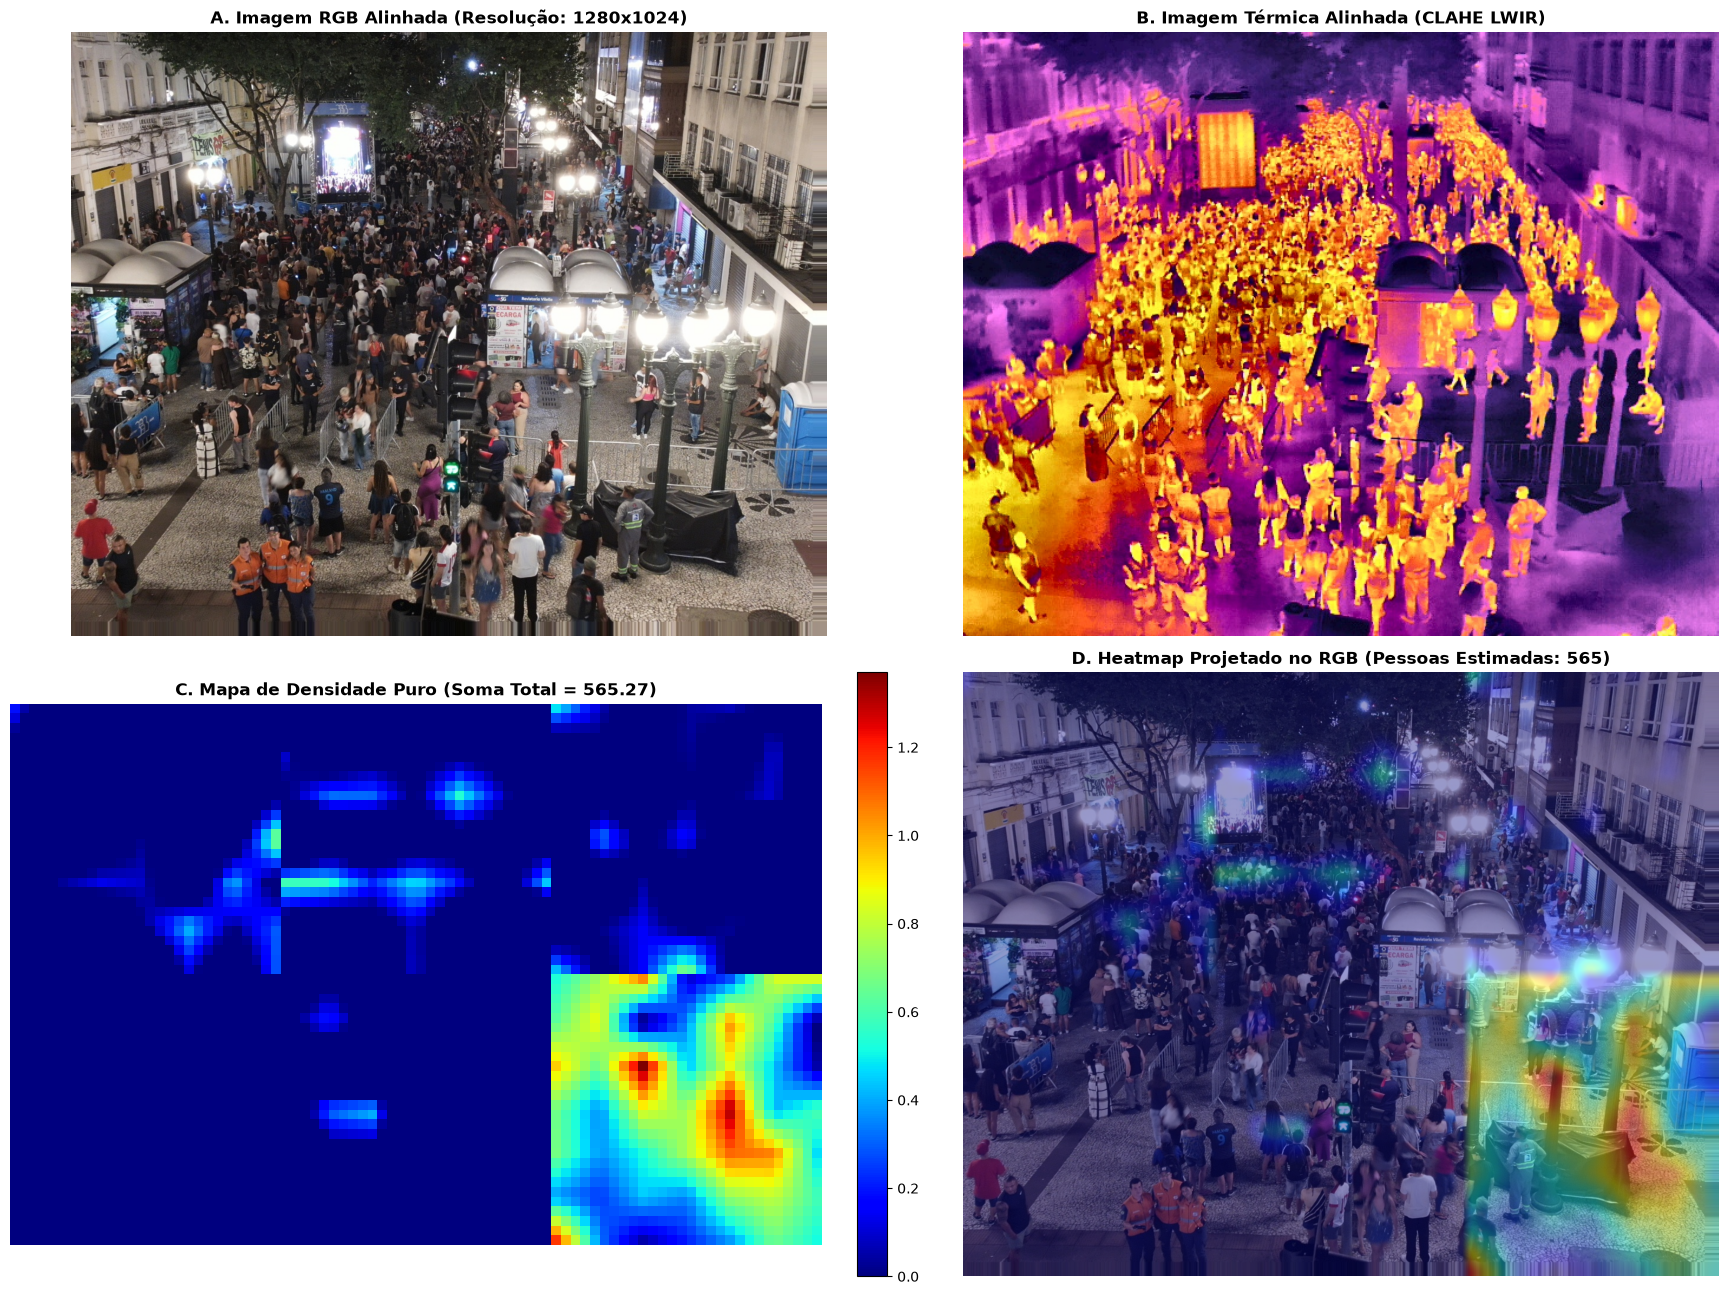

[*] Painel consolidado 2x2 salvo em: C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\painel_contagem_multimodal.jpg


In [6]:
# Normalização da densidade para o intervalo [0, 255]
d_min, d_max = density_np.min(), density_np.max()
if d_max - d_min > 1e-8:
    d_norm = ((density_np - d_min) / (d_max - d_min) * 255.0).astype(np.uint8)
else:
    d_norm = np.zeros_like(density_np, dtype=np.uint8)

# Aplicar colormap JET
heatmap_jet = cv2.applyColorMap(d_norm, cv2.COLORMAP_JET)
heatmap_jet_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)

# Redimensionar o heatmap para a resolução original do par multimodal
heatmap_full_res = cv2.resize(heatmap_jet_rgb, (orig_w, orig_h), interpolation=cv2.INTER_CUBIC)

# Projeção sobreposta ponderada (60% imagem base + 40% heatmap)
overlay_on_rgb = cv2.addWeighted(img_rgb, 0.60, heatmap_full_res, 0.40, 0)
overlay_on_th = cv2.addWeighted(img_th, 0.60, heatmap_full_res, 0.40, 0)

# Renderizar painel consolidado 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"A. Imagem RGB Alinhada (Resolução: {orig_w}x{orig_h})", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_th)
axes[0, 1].set_title(f"B. Imagem Térmica Alinhada (CLAHE LWIR)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

im_d = axes[1, 0].imshow(density_np, cmap="jet")
axes[1, 0].set_title(f"C. Mapa de Densidade Puro (Soma Total = {integral_count:.2f})", fontsize=12, fontweight="bold")
axes[1, 0].axis("off")
plt.colorbar(im_d, ax=axes[1, 0], fraction=0.035, pad=0.04)

axes[1, 1].imshow(overlay_on_rgb)
axes[1, 1].set_title(f"D. Heatmap Projetado no RGB (Pessoas Estimadas: {estimated_people})", fontsize=12, fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "painel_contagem_multimodal.jpg"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Painel consolidado 2x2 salvo em: {panel_path}")


## 7. Auditoria Espacial em Alta Resolução (ROI Zoom em Pedestres)
Para validar o comportamento da inteligência artificial, fazemos um zoom na região de interesse (*Region of Interest - ROI*) onde se concentram os pedestres no solo. Observamos a perfeita correspondência entre a pessoa visível, sua assinatura térmica e a ativação do mapa de densidade.


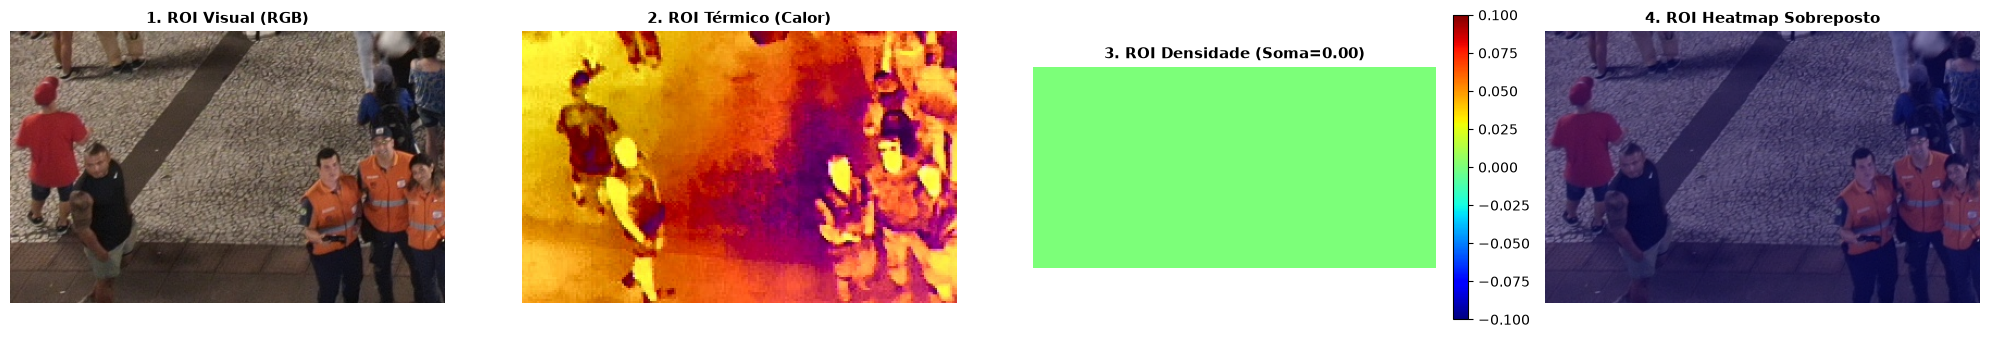

[*] Auditoria de ROI salva em: C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\zoom_roi_pedestres_densidade.jpg


In [7]:
# Região de interesse dos pedestres (solo inferior esquerdo)
y1, y2, x1, x2 = 750, 1000, 0, 400

roi_rgb = img_rgb[y1:y2, x1:x2]
roi_th = img_th[y1:y2, x1:x2]
roi_heatmap_overlay = overlay_on_rgb[y1:y2, x1:x2]

# Recortar densidade correspondente
h_scale = density_np.shape[0] / orig_h
w_scale = density_np.shape[1] / orig_w
ry1, ry2 = int(y1 * h_scale), int(y2 * h_scale)
rx1, rx2 = int(x1 * w_scale), int(x2 * w_scale)
roi_density = density_np[ry1:ry2, rx1:rx2]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(roi_rgb)
axes[0].set_title("1. ROI Visual (RGB)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(roi_th)
axes[1].set_title("2. ROI Térmico (Calor)", fontsize=11, fontweight="bold")
axes[1].axis("off")

im_roi = axes[2].imshow(roi_density, cmap="jet")
axes[2].set_title(f"3. ROI Densidade (Soma={roi_density.sum():.2f})", fontsize=11, fontweight="bold")
axes[2].axis("off")
plt.colorbar(im_roi, ax=axes[2], fraction=0.035, pad=0.04)

axes[3].imshow(roi_heatmap_overlay)
axes[3].set_title("4. ROI Heatmap Sobreposto", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.tight_layout()
roi_path = OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"
plt.savefig(str(roi_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Auditoria de ROI salva em: {roi_path}")


## 8. Exportação dos Artefatos Finais e Telemetria em JSON
Gravamos todos os resultados estruturados no disco:
1. Imagens renderizadas (`painel_contagem_multimodal.jpg`, `heatmap_sobre_rgb.jpg`, `heatmap_sobre_termica.jpg`).
2. Matriz de densidade em formato binário NumPy (`density_map.npy`) para processamento posterior.
3. Arquivo de telemetria `telemetria_contagem.json` contendo latência, estatísticas de multidão e referências de arquivos.


In [8]:
f_rgb_overlay = OUTPUT_DIR / "heatmap_sobre_rgb.jpg"
f_th_overlay = OUTPUT_DIR / "heatmap_sobre_termica.jpg"
f_raw_heatmap = OUTPUT_DIR / "heatmap_puro_densidade.jpg"
npy_path = OUTPUT_DIR / "density_map.npy"
telemetry_path = OUTPUT_DIR / "telemetria_contagem.json"

# Gravar imagens
cv2.imwrite(str(f_rgb_overlay), cv2.cvtColor(overlay_on_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(f_th_overlay), cv2.cvtColor(overlay_on_th, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(f_raw_heatmap), heatmap_jet)

# Gravar matriz de densidade bruta (.npy)
np.save(str(npy_path), density_np)

# Gravar telemetria estruturada em JSON
telemetry = {
    "projeto": "contagem-de-pessoas-def-rgbtcc",
    "etapa": "02_contagem_pessoas_rgbtcc",
    "modelo_utilizado": model_name,
    "dispositivo_hardware": str(device),
    "insumo_entrada": {
        "rgb_preprocessed": str(p_rgb),
        "thermal_preprocessed": str(p_th)
    },
    "resultados": {
        "contagem_pessoas_estimada": int(estimated_people),
        "soma_integral_densidade": float(round(integral_count, 2)),
        "tempo_inferencia_ms": float(round(latency_ms, 2)),
        "densidade_minima": float(round(float(density_np.min()), 5)),
        "densidade_maxima": float(round(float(density_np.max()), 5))
    },
    "artefatos_gerados": {
        "painel_2x2": str(panel_path),
        "zoom_roi": str(roi_path),
        "heatmap_rgb": str(f_rgb_overlay),
        "heatmap_termica": str(f_th_overlay),
        "mapa_densidade_npy": str(npy_path)
    }
}

with open(telemetry_path, "w", encoding="utf-8") as f:
    json.dump(telemetry, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("             ARTEFATOS EXPORTADOS COM SUCESSO")
print("=" * 65)
print(f"1. Telemetria JSON:      {telemetry_path}")
print(f"2. Matriz Densidade:     {npy_path}")
print(f"3. Painel Consolidado:   {panel_path}")
print(f"4. Heatmap sobre RGB:    {f_rgb_overlay}")
print(f"5. Heatmap sobre Térmico: {f_th_overlay}")
print("=" * 65)
print("Pipeline Completo RGBT executado de ponta a ponta com sucesso!")


             ARTEFATOS EXPORTADOS COM SUCESSO
1. Telemetria JSON:      C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\telemetria_contagem.json
2. Matriz Densidade:     C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\density_map.npy
3. Painel Consolidado:   C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\painel_contagem_multimodal.jpg
4. Heatmap sobre RGB:    C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\heatmap_sobre_rgb.jpg
5. Heatmap sobre Térmico: C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\heatmap_sobre_termica.jpg
Pipeline Completo RGBT executado de ponta a ponta com sucesso!
